In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
##Read the dataset
df = pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [7]:
df.shape

(23, 2)

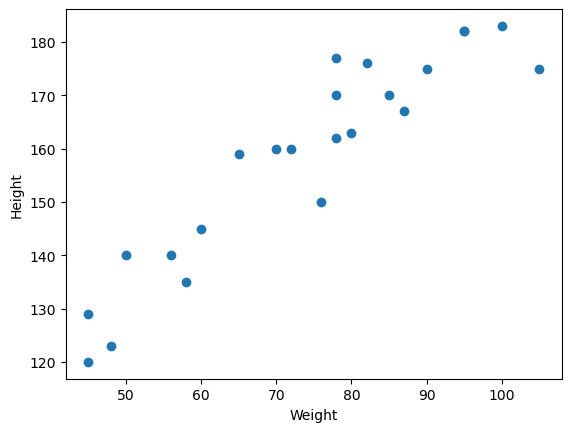

In [10]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
##divide our dataset into independent and dependent features
x = df[['Weight']]
y = df['Height']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [14]:
y_train

12    175
1     135
13    183
5     162
2     123
11    182
20    129
3     145
4     160
18    150
16    140
21    140
22    160
7     175
10    176
14    170
19    167
6     163
Name: Height, dtype: int64

In [15]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

In [16]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

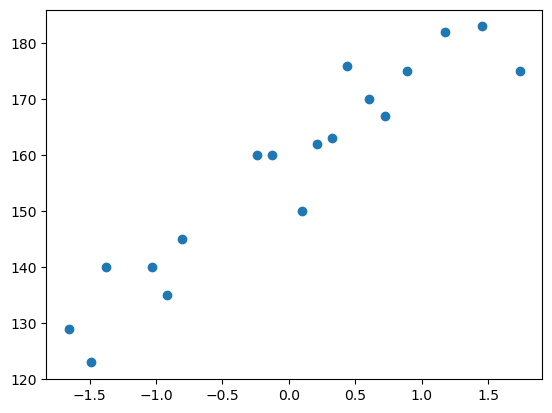

In [18]:
plt.scatter(x_train,y_train)
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
regression = LinearRegression()

In [21]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
type(x_train)

numpy.ndarray

In [23]:
x_train = np.array(x_train).reshape(-1,1)
x_test = np.array(x_test).reshape(-1,1)

In [24]:
y_train.shape

(18,)

In [25]:
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
## coefficient and intercepts
print("Coefficient:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient: [17.03440872]
Intercept: 157.5


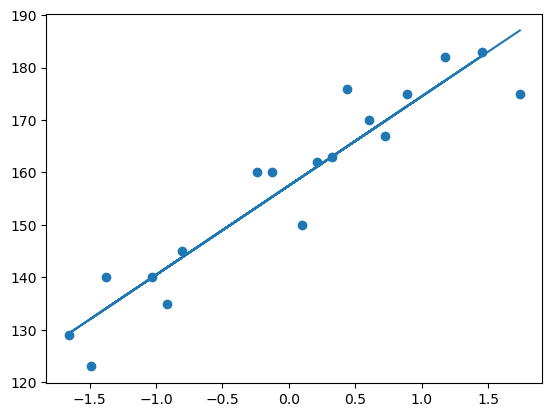

In [27]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [28]:
y_pred_test = regression.predict(x_test)

In [29]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

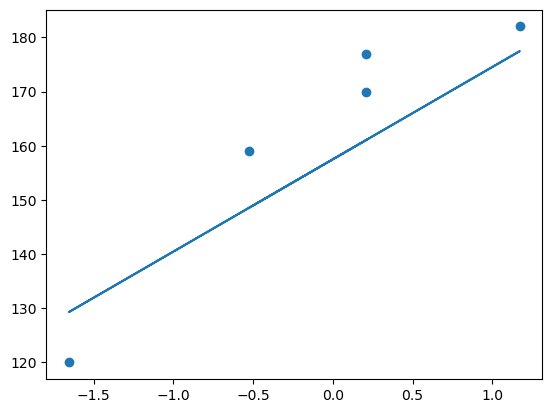

In [30]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regression.predict(x_test))

In [31]:
### Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


### R square
Formula

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [34]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
print(score)

0.776986986042344


### Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [39]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.7026493147231252

In [41]:
regression.predict(scaler.transform([[75]]))

d:\Anocanda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([158.19553315])